# Cost change of oil before and after Hormuz crisis in 2026

## Load the Data
Using data from dataloader (Data_Loader\dataloader_oil.py)

In [ ]:
import sys

sys.path.insert(0, 'Data\raw')
sys.path.insert(0, 'Data_Loader')

from Data_Loader import dataloader_oil

In [2]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt

In [3]:
import os
print("Current Working Directory:", os.getcwd())

print("Local Folder Contents:", os.listdir("."))

Current Working Directory: c:\Users\eye24\OneDrive\ドキュメント\GitHub\AI-Immigration\Visualisation_Board
Local Folder Contents: ['Bypass_Pipeline_Capacity_(Aston).ipynb', 'Change_in_Malacca_Volumes_(Akylai).ipynb', 'Cost-Burden_Analysis2_(Ai & Ririka).ipynb', 'Hormuz_flow_visualization_(Ririka).ipynb', 'Impacts_on_Global_Oil_Trade_(Mami).ipynb', 'NotinUse_Cost-Burden_Analysis_(Ai & Ririka).ipynb', 'Visualisation_Board']


In [4]:
import sys
from pathlib import Path

parent_dir = str(Path("..").resolve())

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

data_loaders_dir = str((Path("..") / "Data_loaders").resolve())
if data_loaders_dir not in sys.path:
    sys.path.append(data_loaders_dir)

from Data_loaders import dataloader_oil

Check point for load_oil_prices
Check point for load_oil_prices_csv
Check point for _fallback_oil_prices


In [5]:
df = dataloader_oil.load_oil_prices()  

print(df.head())
print(df.info())

           date                                             region  \
797  1960-01-31  Crude oil price (USD/bbl) - World average - Wo...   
2391 1960-01-31  Crude oil price (USD/bbl) - Asia - World Bank ...   
1594 1960-01-31  Crude oil price (USD/bbl) - Europe - World Ban...   
1595 1960-02-29  Crude oil price (USD/bbl) - Europe - World Ban...   
2392 1960-02-29  Crude oil price (USD/bbl) - Asia - World Bank ...   

      price_usd_bbl  
797            1.63  
2391           1.63  
1594           1.63  
1595           1.63  
2392           1.63  
<class 'pandas.core.frame.DataFrame'>
Index: 2924 entries, 797 to 3984
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2924 non-null   datetime64[ns]
 1   region         2924 non-null   object        
 2   price_usd_bbl  2924 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 91.4+ KB
None


C:\Users\eye24\OneDrive\ドキュメント\GitHub\AI-Immigration\Data_loaders\dataloader_oil.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[date_col] = pd.to_datetime(


In [6]:
df.head()

,date,region,price_usd_bbl
797,1960-01-31,Crude oil price (USD/bbl) - World average - Wo...,1.63
2391,1960-01-31,Crude oil price (USD/bbl) - Asia - World Bank ...,1.63
1594,1960-01-31,Crude oil price (USD/bbl) - Europe - World Ban...,1.63
1595,1960-02-29,Crude oil price (USD/bbl) - Europe - World Ban...,1.63
2392,1960-02-29,Crude oil price (USD/bbl) - Asia - World Bank ...,1.63


In [7]:
df.query("date > 2021")

,date,region,price_usd_bbl
2326,2021-01-31,Crude oil price (USD/bbl) - Europe - World Ban...,54.55
1529,2021-01-31,Crude oil price (USD/bbl) - World average - Wo...,53.60
3123,2021-01-31,Crude oil price (USD/bbl) - Asia - World Bank ...,54.16
3920,2021-01-31,Crude oil price (USD/bbl) - North America - Wo...,52.10
1530,2021-02-28,Crude oil price (USD/bbl) - World average - Wo...,60.46
...,...,...,...
1592,2026-04-30,Crude oil price (USD/bbl) - World average - Wo...,103.91
1593,2026-05-31,Crude oil price (USD/bbl) - World average - Wo...,100.43
3187,2026-05-31,Crude oil price (USD/bbl) - Asia - World Bank ...,94.67
2390,2026-05-31,Crude oil price (USD/bbl) - Europe - World Ban...,107.54


### Annual Change

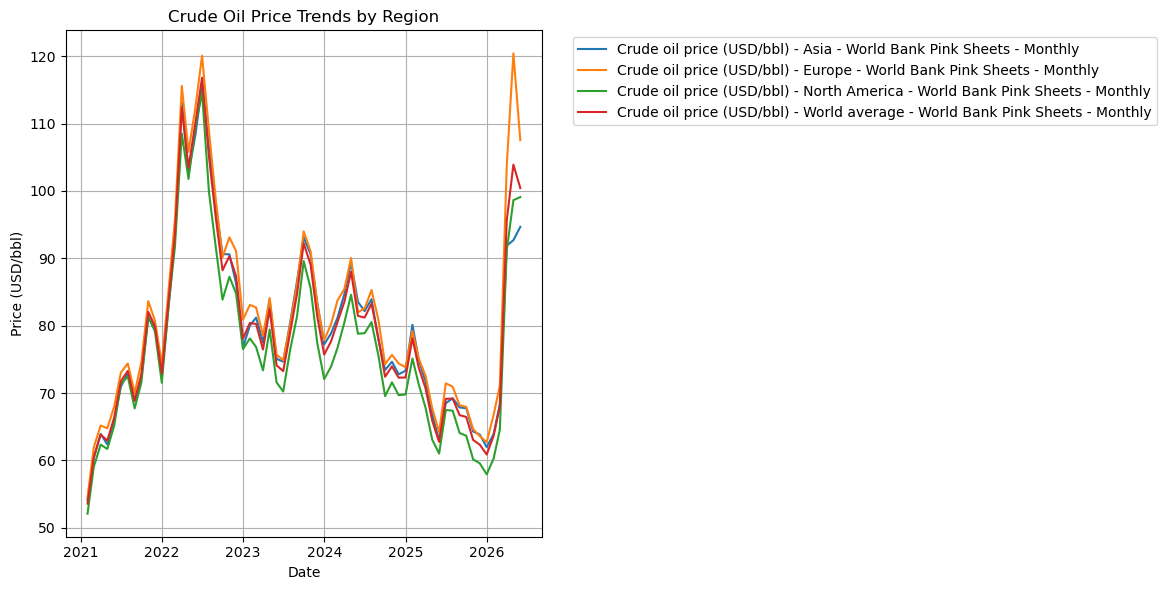

In [8]:
import matplotlib.pyplot as plt

filtered_df = df.query("date > 2021")

plt.rcParams["figure.figsize"] = (12, 6)

for region_name, group in filtered_df.groupby('region'):
    plt.plot(group['date'], group['price_usd_bbl'], label=region_name)


plt.title('Crude Oil Price Trends by Region')
plt.xlabel('Date')
plt.ylabel('Price (USD/bbl)')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


plt.grid(True)

plt.tight_layout()

### Monthly Change

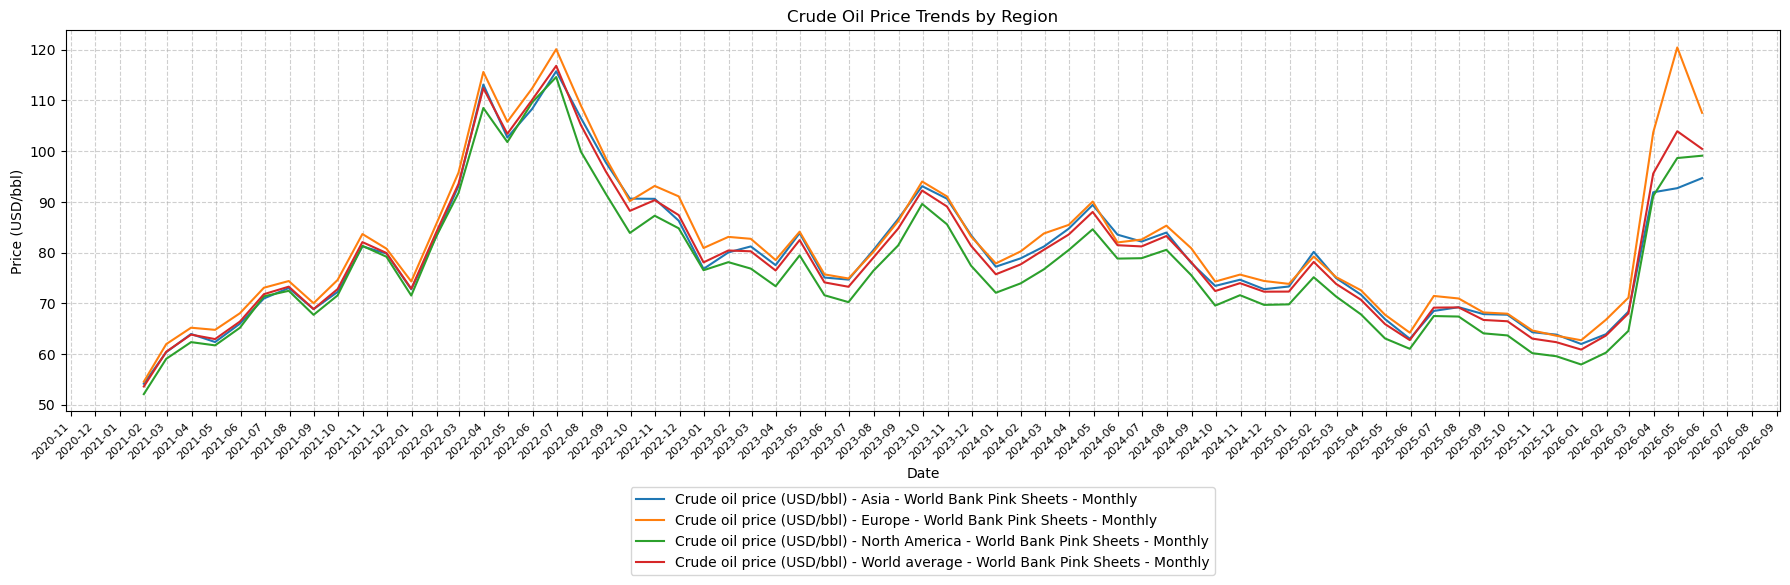

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates  

filtered_df = df.query("date > 2021")

fig, ax = plt.subplots(figsize=(18, 6))

for region_name, group in filtered_df.groupby('region'):
    ax.plot(group['date'], group['price_usd_bbl'], label=region_name)


ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.autofmt_xdate()
plt.xticks(fontsize=8, rotation=45)


plt.title('Crude Oil Price Trends by Region')
plt.xlabel('Date')
plt.ylabel('Price (USD/bbl)')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=1)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()


## Data Interpretation
The global average oil price increased by approximately $20 per barrel between March and April 2026. This surge was led by Europe, which saw the sharpest increase at $35 per barrel. This upward trend persisted into May, pushing the global average to $105 per barrel, while European prices broke past the $120 mark.
In contrast, the price increase in the Asian market was relatively moderate. While Asian prices did rise by around $20 per barrel in March, the subsequent growth trajectory remained gradual. This stability was likely because several Asian countries managed to secure oil supplies from Russia; by maintaining these robust inventories, they avoided the need to buy oil at high spot prices, unlike European countries. 

